### Baseline comparison
#### Last modified: 08/25/2025
#### Author: Landon Buskirk 

In [ ]:
import scripts.suppl_baseline_data_functions as dfc
import scripts.suppl_baseline_comparison_function as cf
import pandas as pd
import time
import numpy as np
import shelve
import argparse
from datetime import date
import os

In [90]:
qn_drug_lv3data = shelve.open("data/expression/drug_data/qn_drug_lv3data") 
qndrug_target_vec_ = qn_drug_lv3data['qndrug_target_vec']
drug_data = qn_drug_lv3data['drug_data_qn']
landmark_genes = drug_data.index.values
rnaseq_dis_data_old, marray_dis_data_old = dfc.read_dis_data(landmark_genes)

In [69]:
drug_data

,LJP005_A375_24H_B19:A03,LJP005_A375_24H_B19:A04,LJP005_A375_24H_B19:A05,LJP005_A375_24H_B19:A06,LJP005_A375_24H_B19:B03,LJP005_A375_24H_B19:B04,LJP005_A375_24H_B19:B05,LJP005_A375_24H_B19:B06,LJP005_A375_24H_B19:F07,LJP005_A375_24H_B19:F08,...,REP.A028_YAPC_24H_B25:F09,REP.A028_YAPC_24H_B25:F10,REP.A028_YAPC_24H_B25:F11,REP.A028_YAPC_24H_B25:F12,REP.A028_YAPC_24H_B25:J13,REP.A028_YAPC_24H_B25:J14,REP.A028_YAPC_24H_B25:J15,REP.A028_YAPC_24H_B25:J16,REP.A028_YAPC_24H_B25:J17,REP.A028_YAPC_24H_B25:J18
rid,,,,,,,,,,,,,,,,,,,,,
5720,11.543965,11.510558,11.430315,11.266377,11.543965,11.612832,11.577747,11.238309,11.169989,11.494523,...,13.278962,13.278962,13.533735,13.441488,13.144819,13.634435,13.441488,13.441488,13.441488,13.441488
466,7.645389,7.699559,7.486614,7.474133,7.590786,7.505121,7.952670,7.735502,7.548140,7.675566,...,7.765098,7.917945,7.776995,7.806839,7.303048,7.741477,7.923720,8.102007,7.836218,7.681595
6009,11.527134,11.543965,11.779896,11.860454,11.595319,11.839470,11.722370,11.741305,11.722370,11.543965,...,11.881306,11.902598,11.779896,11.924068,12.116607,11.902598,11.946233,12.040367,12.090492,11.760431
2309,5.753854,5.570784,6.154816,5.775626,5.731591,5.893603,5.808799,5.709201,6.116086,5.742762,...,6.097205,6.125775,6.970357,6.087066,5.570784,6.145348,6.338715,6.570608,6.266413,6.636563
387,9.580054,9.560438,9.495424,9.307379,9.086409,9.109910,9.553888,9.813962,9.469902,9.508277,...,6.991777,6.266413,6.770671,6.461225,7.753266,6.660781,6.770671,6.861566,6.905522,6.762878
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23200,8.148063,8.761851,8.560743,8.440268,8.234051,8.388929,8.268478,7.935326,8.079095,8.016018,...,9.356874,8.911562,9.793360,9.121709,9.444289,9.732703,9.127682,9.363059,9.180881,9.139406
51293,10.928015,11.032125,10.996768,10.062768,10.123030,9.820832,10.996768,11.105411,11.092983,10.026059,...,9.489019,9.204566,9.319812,9.015918,10.356514,9.679003,8.957925,9.612747,9.692300,9.705717
10962,11.043982,11.461961,11.032125,12.731211,11.527134,10.928015,11.043982,11.309150,11.197058,10.679184,...,5.245558,9.313596,7.492798,9.240375,6.294092,11.860454,7.277054,7.411462,5.128469,7.360941


In [ ]:
dis_meta = pd.read_csv('data/annotation/Homo_sapiens.gene_info.csv', header=[0], index_col=[0]) # old?
meta = pd.read_csv('data/metadata/clean_TB_sample_metadata_classification.tsv', sep='\t')
new_gsm_control = meta.loc[meta['CLASSIFICATION']=='healthy control without treatment', 'geo_accession'].values
rnaseq_dis_data, marray_dis_data = dfc.read_dis_data(landmark_genes, control_samples=new_gsm_control)
rnaseq_tissue = meta.set_index('geo_accession').loc[rnaseq_dis_data.columns.values, 'TISSUE'].fillna('Missing')
rnaseq_cell = meta.set_index('geo_accession').loc[rnaseq_dis_data.columns.values, 'CELL'].fillna('Missing')

In [4]:
rnaseq_dis_data

Disease Samples,GSM2695727,GSM2695728,GSM2695731,GSM2695732,GSM2695735,GSM2695738,GSM7518958,GSM7518960,GSM7518962,GSM7518964,...,GSM3071039,GSM3071041,GSM3071043,GSM3071045,GSM3071049,GSM3071051,GSM3071053,GSM3071055,GSM3071057,GSM3071059
GeneID,,,,,,,,,,,,,,,,,,,,,
5720,768.0,811.0,727.0,962.0,2195.0,1317.0,1375.0,1258.0,1777.0,2568.0,...,925.0,1550.0,1250.0,1456.0,2972.0,4931.0,2825.0,3250.0,2942.0,1277.0
466,148.0,122.0,101.0,108.0,277.0,182.0,384.0,324.0,475.0,468.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6009,603.0,549.0,685.0,544.0,1172.0,984.0,1932.0,1776.0,1497.0,1737.0,...,921.0,562.0,552.0,285.0,852.0,1068.0,1170.0,1477.0,650.0,1593.0
2309,565.0,588.0,559.0,539.0,1178.0,904.0,1384.0,881.0,1264.0,991.0,...,994.0,897.0,1144.0,844.0,2152.0,525.0,985.0,1686.0,42.0,1097.0
387,3146.0,3572.0,3474.0,3778.0,6193.0,7543.0,10858.0,12353.0,11872.0,17329.0,...,8677.0,8068.0,6650.0,5787.0,8359.0,12456.0,5955.0,10283.0,9800.0,9227.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23200,1016.0,1164.0,981.0,1126.0,1663.0,1433.0,1669.0,1459.0,1981.0,1495.0,...,614.0,576.0,748.0,565.0,2004.0,3.0,1025.0,1614.0,307.0,364.0
51293,16.0,15.0,25.0,18.0,45.0,35.0,40.0,55.0,29.0,12.0,...,27.0,62.0,118.0,175.0,135.0,808.0,784.0,356.0,413.0,157.0
10962,11.0,13.0,10.0,16.0,29.0,51.0,25.0,29.0,22.0,29.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [73]:
cell_lines = list(set([x.split('_')[1] for x in drug_data.columns]))

# Number of columns per cell line
cell_line_counts = {
    cell_line: sum(cell_line in col for col in drug_data.columns)
    for cell_line in cell_lines
}
cell_line_counts

{'CD34': 94,
 'SKL': 164,
 'HUES3': 22,
 'HT29': 802,
 'HME1': 98,
 'LNCAP': 26,
 'YAPC': 699,
 'ASC.C': 72,
 'NPC.TAK': 72,
 'SKL.C': 94,
 'HUVEC': 94,
 'HA1E': 763,
 'JURKAT': 22,
 'PC3': 792,
 'NPC.CAS9': 72,
 'MCF7': 854,
 'MNEU.E': 22,
 'MDAMB231': 52,
 'ASC': 215,
 'HEPG2': 124,
 'NEU': 94,
 'NPC': 216,
 'MCF10A': 52,
 'BT20': 52,
 'A375': 764,
 'HELA': 638,
 'SKBR3': 52,
 'HCC515': 124,
 'A549': 124,
 'HS578T': 52}

In [ ]:
group = 'stouffer' # 'avg_cell_line', 'stouffer', 'none'

if group == 'avg_cell_line':
    # group drug samples by cell line -> drug_data_cell
    cell_lines = list(set([x.split('_')[1] for x in drug_data.columns]))
    drug_data_cell = pd.DataFrame(index=drug_data.index, columns=cell_lines)
    for cell_line in cell_lines:
        cell_line_columns = [x for x in drug_data.columns if cell_line in x]
        drug_data_cell[cell_line] = drug_data[cell_line_columns].mean(axis=1)
    drug_data = drug_data_cell
elif group == 'stouffer':
    # group drug samples by cell line -> drug_data_cell
    cell_lines = list(set([x.split('_')[1] for x in drug_data.columns]))

    drug_data_cell = pd.DataFrame(index=drug_data.index, columns=cell_lines)
    for cell_line in cell_lines:
        cell_line_columns = [x for x in drug_data.columns if cell_line in x]
        weights = []
        for col in cell_line_columns:
            correlations = []
            for col2 in cell_line_columns:
                if col != col2:
                    correlations.append(np.corrcoef(drug_data[col], drug_data[col2])[0][1])
            avg_corr = np.mean(correlations)
            avg_corr = 0 if avg_corr<0.05 else avg_corr
            weights.append(np.mean(correlations))
        weights = np.array(weights)
        weights = weights/np.sum(weights)
        drug_data_cell[cell_line] = np.sum(drug_data[cell_line_columns].values * weights, axis=1)


def qnorm_dis_data(dis_data, target_vec):
    dis_data_qn = dis_data.copy()
    target_vec = np.sort(np.array(target_vec))
    for col in dis_data_qn.columns:
        t = np.searchsorted(np.sort(dis_data[col]), dis_data[col])
        dis_data_qn.loc[:,col] = [target_vec[i] for i in t]
    return dis_data_qn.astype('float64')

rnaseq_dis_data.dropna(inplace=True)
rnaseq_genes = rnaseq_dis_data.index
rnaseq_dis_data_qn = qnorm_dis_data(rnaseq_dis_data, qndrug_target_vec_.loc[rnaseq_genes])
# marray_dis_data.dropna(inplace=True)
# marray_genes = marray_dis_data.index
# marray_dis_data_qn = qnorm_dis_data(marray_dis_data, qndrug_target_vec_)

types = np.array(['pearson'])

def save_ranks(drug_data, dis_data, filename):
    # 3D array: [drug, dis, corr]
    arr_3d = cf.get_correlations(drug_data, dis_data, 
                                correlation_type=types).astype('float32')
    
    # List of dataframes: [drug, dis]
    corr_matrices = [pd.DataFrame(arr_3d[:,:,i].T, index=drug_data.columns, 
                                columns=dis_data.columns) 
                    for i in range(arr_3d.shape[2])]
    
    for i, mat in enumerate(corr_matrices):
        mat.to_csv(f'{filename}{types[i][0]}_{str(date.today())[5:]}.csv')

drug_data_rna_subset = drug_data_cell.loc[rnaseq_genes]
# drug_data_marray_subset = drug_data.loc[marray_genes]

save_ranks(drug_data_rna_subset, rnaseq_dis_data_qn, f'results/rna_ranks_')
# save_ranks(drug_data_marray_subset, marray_dis_data_qn, f'results/marray_ranks_')


In [ ]:
#'stouffer':
# Group drug samples by cell line with Stouffer-like weighting
cell_lines = list(set([x.split('_')[1] for x in drug_data.columns]))
drug_data_cell = pd.DataFrame(index=drug_data.index, columns=cell_lines)
for cell_line in cell_lines:
    cell_line_columns = [x for x in drug_data.columns if cell_line in x]
    weights = []
    for col in cell_line_columns:
        correlations = []
        for col2 in cell_line_columns:
            if col != col2:
                corr = np.corrcoef(drug_data[col], drug_data[col2])[0,1]
                correlations.append(corr)
        avg_corr = np.mean(correlations)
        avg_corr = 0 if avg_corr < 0.05 else avg_corr
        weights.append(avg_corr)
    weights = np.array(weights)
    weights = weights / np.sum(weights)
    drug_data_cell[cell_line] = np.sum(drug_data[cell_line_columns].values * weights, axis=1)

correlation_type = np.array(['pearson'])  # or ['pearson','spearman',...]
all_corrs = {}

for corr_type in correlation_type:
    corr_df = pd.DataFrame(index=drug_data_cell.columns, columns=drug_data_cell.columns, dtype=float)
    for col in drug_data_cell.columns:
        # get_correlations expects dis_sample as a Series
        result = cf.get_correlations(drug_data_cell, drug_data_cell[col], correlation_type=[corr_type])
        # result is a 1-column dataframe with index = drug_data.columns
        corr_df.loc[:, col] = result[corr_type]
    all_corrs[corr_type] = corr_df

# --- Save results ---
for corr_type, mat in all_corrs.items():
    mat.to_csv(f'results/drug_by_drug_{corr_type}_{str(date.today())[5:]}.csv')

In [36]:
rnaseq_tissue.value_counts()

TISSUE
blood      135
lung        84
BALF        22
BAL         16
HEPG2        8
Missing      6
PBMC         3
Name: count, dtype: int64

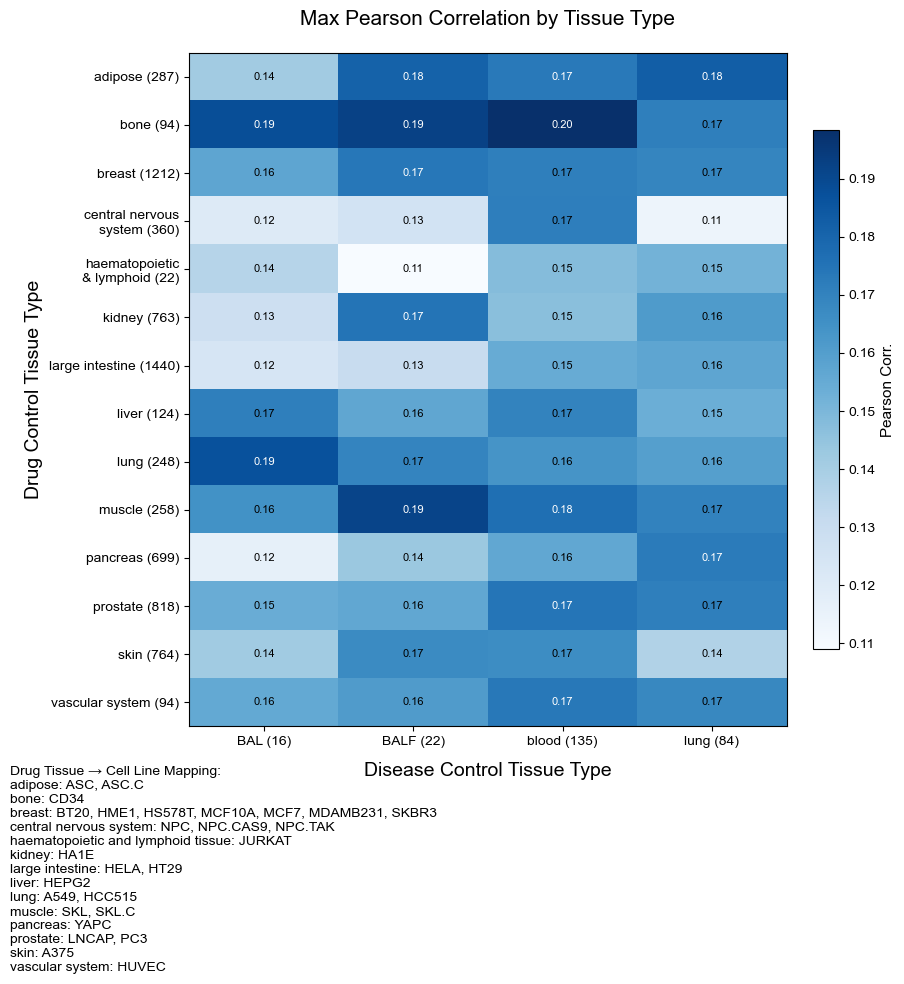

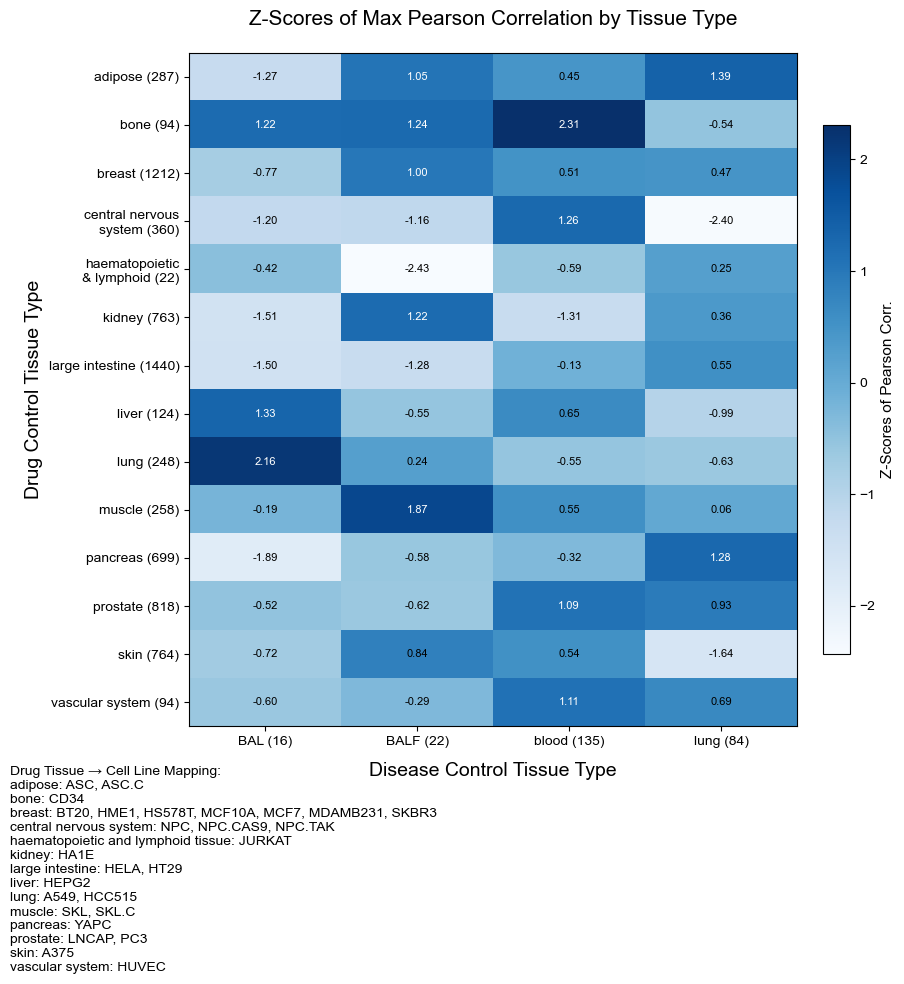

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import json
from collections import defaultdict

p = pd.read_csv('results/rna_ranks_p_09-01.csv', index_col=0)

# read in 'cell_line_to_tissue.json'
with open('results/cell_line_to_tissue.json', 'r') as f:
    cell_line_tissues = json.load(f)

# Group: tissue → list of cell lines/samples
drug_tissue_groups = defaultdict(list)
for cl, tissue in cell_line_tissues.items():
    drug_tissue_groups[tissue].append(cl)

# disease tissues
disease_tissue_groups = defaultdict(list)
tiss = rnaseq_tissue.value_counts()[rnaseq_tissue.value_counts() > 10].index
for sample, tissue in rnaseq_tissue[rnaseq_tissue.isin(tiss)].items():
    disease_tissue_groups[tissue].append(sample)

# Build tissue x tissue median correlation matrix
drug_tissues = sorted(drug_tissue_groups.keys())
disease_tissues = sorted(disease_tissue_groups.keys())
tissue_matrix = pd.DataFrame(index=drug_tissues, columns=disease_tissues, dtype=float)

for dt in drug_tissues:
    for ds in disease_tissues:
        cell_lines = drug_tissue_groups[dt]
        samples = disease_tissue_groups[ds]
        submatrix = p.loc[p.index.intersection(cell_lines), p.columns.intersection(samples)]
        if not submatrix.empty:
            tissue_matrix.loc[dt, ds] = np.max(submatrix.values)

matrix = tissue_matrix.values.astype(float)[1:, :]

def safe_zscore(matrix, axis):
    mean = np.nanmean(matrix, axis=axis, keepdims=True)  
    std = np.nanstd(matrix, axis=axis, ddof=1, keepdims=True)  
    return (matrix - mean) / std  

row_z_scores = safe_zscore(matrix, axis=1)
col_z_scores = safe_zscore(matrix, axis=0)
matrix_zscores = (row_z_scores + col_z_scores) / np.sqrt(2)

mpl.rcParams['font.family'] = 'Arial'

# Shortened names
dis_tis_name_map = {
    'primary human lymphatic endothelial cell': 'lymphatic endothelial', 
    'PBMCs isolated from Healthy individuals' : 'PBMC',
    'Purified cord blood CD34+ cells': 'cord blood CD34+',
    'monocyte-derived macrophages': 'macrophages',
}
drug_tis_name_map = {
    'haematopoietic and lymphoid tissue': 'haematopoietic\n& lymphoid',
    'central nervous system': 'central nervous\nsystem',
}

# --- Function to add counts to tick labels ---
def add_counts_to_labels(tissues, groups, name_map):
    labels = []
    for t in tissues:
        pretty_name = name_map.get(t, t)
        count = len(groups[t])
        labels.append(f"{pretty_name} ({count})")
    return labels

# tissue -> total number of drug samples (columns) across its cell lines
drug_tissue_sample_counts = {
    tissue: sum(cell_line_counts[cl] for cl in cl_list)
    for tissue, cl_list in drug_tissue_groups.items()
}

def add_counts_to_labels_with_samples(tissues, name_map, sample_counts_dict):
    labels = []
    for t in tissues:
        pretty_name = name_map.get(t, t)
        count = sample_counts_dict.get(t, 0)
        labels.append(f"{pretty_name} ({count})")
    return labels

# Use this for drug tissue labels
ylabels = add_counts_to_labels_with_samples(
    drug_tissues[1:], drug_tis_name_map, drug_tissue_sample_counts
)

# Labels with counts
xlabels = add_counts_to_labels(disease_tissues, disease_tissue_groups, dis_tis_name_map)
# ylabels = add_counts_to_labels(drug_tissues[1:], drug_tissue_groups, drug_tis_name_map)

# --- Function to plot heatmap and add dict key ---
def plot_heatmap(matrix, xlabels, ylabels, title, cbar_label, cmap='Blues', annotate=True):
    fig, ax = plt.subplots(figsize=(9, 8))
    cax = ax.imshow(matrix, cmap=cmap, aspect='auto')
    clbar = fig.colorbar(cax, ax=ax, orientation='vertical', fraction=0.04, pad=0.04)
    clbar.set_label(cbar_label, fontsize=11)

    if annotate:
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                val = matrix[i, j]
                if not np.isnan(val):
                    ax.text(j, i, f"{val:.2f}", ha='center', va='center',
                            fontsize=8, color='black' if val < np.percentile(matrix, 75) else 'white')

    ax.set_xticks(np.arange(len(xlabels)))
    ax.set_xticklabels(xlabels, rotation=0, fontsize=10)
    ax.set_yticks(np.arange(len(ylabels)))
    ax.set_yticklabels(ylabels, fontsize=10)

    ax.set_xlabel('Disease Control Tissue Type', fontsize=14, labelpad=10)
    ax.set_ylabel('Drug Control Tissue Type', fontsize=14)
    ax.set_title(title, fontsize=15, pad=20)

    # Add the drug tissue → cell line key below the figure 
    drug_key_text = "\n".join([f"{name}: {', '.join(drug_tissue_groups[name])}" for name in drug_tissues[1:]])

    plt.figtext(0, -0.22, "Drug Tissue → Cell Line Mapping:\n" + drug_key_text,
                wrap=False, ha='left', fontsize=10)

    plt.tight_layout()
    plt.show()

# --- Plot both heatmaps ---
plot_heatmap(matrix, xlabels, ylabels,
             'Max Pearson Correlation by Tissue Type',
             
             'Pearson Corr.')

plot_heatmap(matrix_zscores, xlabels, ylabels,
             'Z-Scores of Max Pearson Correlation by Tissue Type',
             'Z-Scores of Pearson Corr.')


In [111]:
drug_key_text = "\n".join([f"{name}: {', '.join(drug_tissue_groups[name])}" for name in drug_tissues[1:]])
print(drug_key_text)

adipose: ASC, ASC.C
bone: CD34
breast: BT20, HME1, HS578T, MCF10A, MCF7, MDAMB231, SKBR3
central nervous system: NPC, NPC.CAS9, NPC.TAK
haematopoietic and lymphoid tissue: JURKAT
kidney: HA1E
large intestine: HELA, HT29
liver: HEPG2
lung: A549, HCC515
muscle: SKL, SKL.C
pancreas: YAPC
prostate: LNCAP, PC3
skin: A375
vascular system: HUVEC


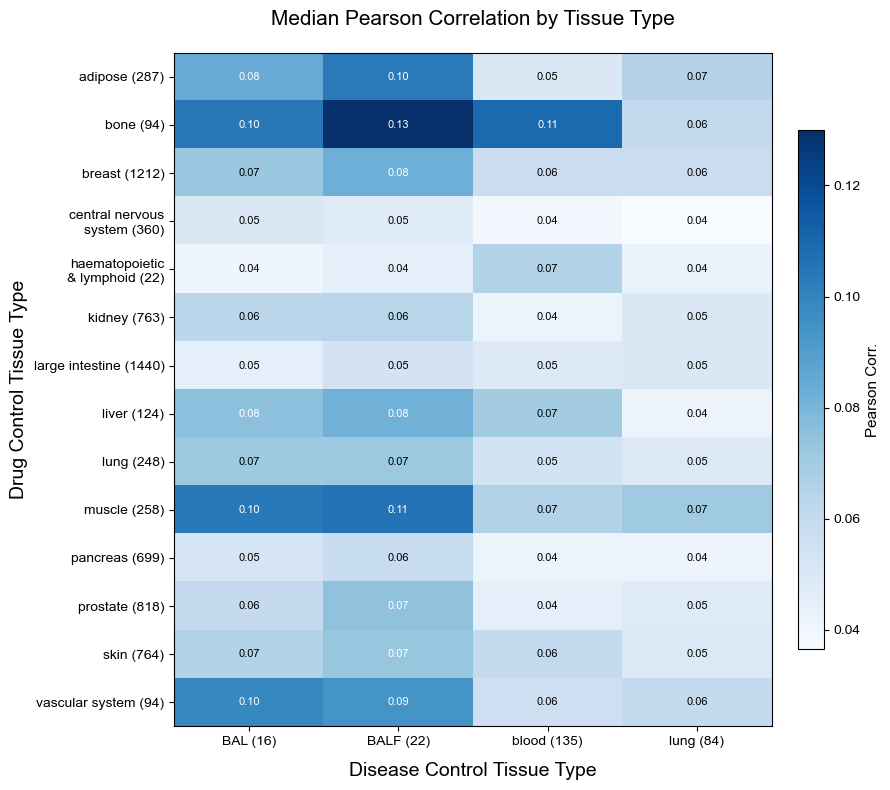

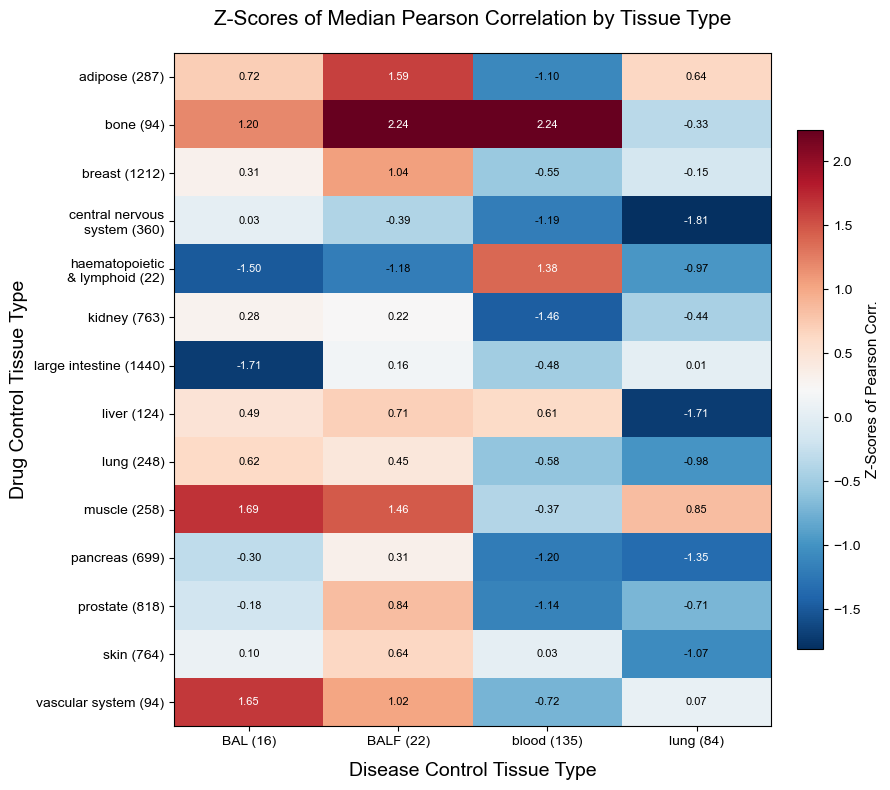

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import json
from collections import defaultdict

p = pd.read_csv('results/rna_ranks_p_09-01.csv', index_col=0)

# read in 'cell_line_to_tissue.json'
with open('results/cell_line_to_tissue.json', 'r') as f:
    cell_line_tissues = json.load(f)

# Group: tissue → list of cell lines/samples
drug_tissue_groups = defaultdict(list)
for cl, tissue in cell_line_tissues.items():
    drug_tissue_groups[tissue].append(cl)

# disease tissues
disease_tissue_groups = defaultdict(list)
tiss = rnaseq_tissue.value_counts()[rnaseq_tissue.value_counts() > 10].index
for sample, tissue in rnaseq_tissue[rnaseq_tissue.isin(tiss)].items():
    disease_tissue_groups[tissue].append(sample)

# Build tissue x tissue median correlation matrix
drug_tissues = sorted(drug_tissue_groups.keys())
disease_tissues = sorted(disease_tissue_groups.keys())
tissue_matrix = pd.DataFrame(index=drug_tissues, columns=disease_tissues, dtype=float)

for dt in drug_tissues:
    for ds in disease_tissues:
        cell_lines = drug_tissue_groups[dt]
        samples = disease_tissue_groups[ds]
        submatrix = p.loc[p.index.intersection(cell_lines), p.columns.intersection(samples)]
        if not submatrix.empty:
            tissue_matrix.loc[dt, ds] = np.median(submatrix.values)

matrix = tissue_matrix.values.astype(float)[1:, :]

def safe_zscore(matrix, axis):
    mean = np.nanmean(matrix, axis=axis, keepdims=True)  
    std = np.nanstd(matrix, axis=axis, ddof=1, keepdims=True)  
    return (matrix - mean) / std  

row_z_scores = safe_zscore(matrix, axis=1)
col_z_scores = safe_zscore(matrix, axis=0)
matrix_zscores = (row_z_scores + col_z_scores) / np.sqrt(2)

mpl.rcParams['font.family'] = 'Arial'

# Shortened names
dis_tis_name_map = {
    'primary human lymphatic endothelial cell': 'lymphatic endothelial', 
    'PBMCs isolated from Healthy individuals' : 'PBMC',
    'Purified cord blood CD34+ cells': 'cord blood CD34+',
    'monocyte-derived macrophages': 'macrophages',
}
drug_tis_name_map = {
    'haematopoietic and lymphoid tissue': 'haematopoietic\n& lymphoid',
    'central nervous system': 'central nervous\nsystem',
}

# --- Function to add counts to tick labels ---
def add_counts_to_labels(tissues, groups, name_map):
    labels = []
    for t in tissues:
        pretty_name = name_map.get(t, t)
        count = len(groups[t])
        labels.append(f"{pretty_name} ({count})")
    return labels

# tissue -> total number of drug samples (columns) across its cell lines
drug_tissue_sample_counts = {
    tissue: sum(cell_line_counts[cl] for cl in cl_list)
    for tissue, cl_list in drug_tissue_groups.items()
}

def add_counts_to_labels_with_samples(tissues, name_map, sample_counts_dict):
    labels = []
    for t in tissues:
        pretty_name = name_map.get(t, t)
        count = sample_counts_dict.get(t, 0)
        labels.append(f"{pretty_name} ({count})")
    return labels

# Use this for drug tissue labels
ylabels = add_counts_to_labels_with_samples(
    drug_tissues[1:], drug_tis_name_map, drug_tissue_sample_counts
)

# Labels with counts
xlabels = add_counts_to_labels(disease_tissues, disease_tissue_groups, dis_tis_name_map)
# ylabels = add_counts_to_labels(drug_tissues[1:], drug_tissue_groups, drug_tis_name_map)

# --- Function to plot heatmap and add dict key ---
def plot_heatmap(matrix, xlabels, ylabels, title, cbar_label, cmap='Blues', annotate=True, center_zero=False):
    fig, ax = plt.subplots(figsize=(9, 8))
    cax = ax.imshow(matrix, cmap=cmap, aspect='auto')
    clbar = fig.colorbar(cax, ax=ax, orientation='vertical', fraction=0.04, pad=0.04)
    clbar.set_label(cbar_label, fontsize=11)

    if center_zero:
        absmax = np.nanmax(np.abs(matrix)) - 0.5
        vmin, vmax = -absmax, absmax
    else:
        vmin, vmax = np.nanmin(matrix), np.nanmax(matrix)

    if annotate:
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                val = matrix[i, j]
                if not np.isnan(val):
                    if center_zero:
                        ax.text(j, i, f"{val:.2f}", ha='center', va='center',
                                fontsize=8, color='black' if abs(val) < (absmax * 0.75) else 'white')
                    else:
                        ax.text(j, i, f"{val:.2f}", ha='center', va='center',
                                fontsize=8, color='black' if val < np.nanpercentile(matrix, 75) else 'white')

    ax.set_xticks(np.arange(len(xlabels)))
    ax.set_xticklabels(xlabels, rotation=0, fontsize=10)
    ax.set_yticks(np.arange(len(ylabels)))
    ax.set_yticklabels(ylabels, fontsize=10)

    ax.set_xlabel('Disease Control Tissue Type', fontsize=14, labelpad=10)
    ax.set_ylabel('Drug Control Tissue Type', fontsize=14)
    ax.set_title(title, fontsize=15, pad=20)

    # Add the drug tissue → cell line key below the figure 
    # drug_key_text = "\n".join([f"{name}: {', '.join(drug_tissue_groups[name])}" for name in drug_tissues[1:]])

    # plt.figtext(0, -0.22, "Drug Tissue → Cell Line Mapping:\n" + drug_key_text,
    #             wrap=False, ha='left', fontsize=10)

    plt.tight_layout()
    plt.show()

# --- Plot both heatmaps ---
plot_heatmap(matrix, xlabels, ylabels,
             'Median Pearson Correlation by Tissue Type',
             'Pearson Corr.')

plot_heatmap(matrix_zscores, xlabels, ylabels,
             'Z-Scores of Median Pearson Correlation by Tissue Type',
             'Z-Scores of Pearson Corr.', cmap='RdBu_r', center_zero=True)


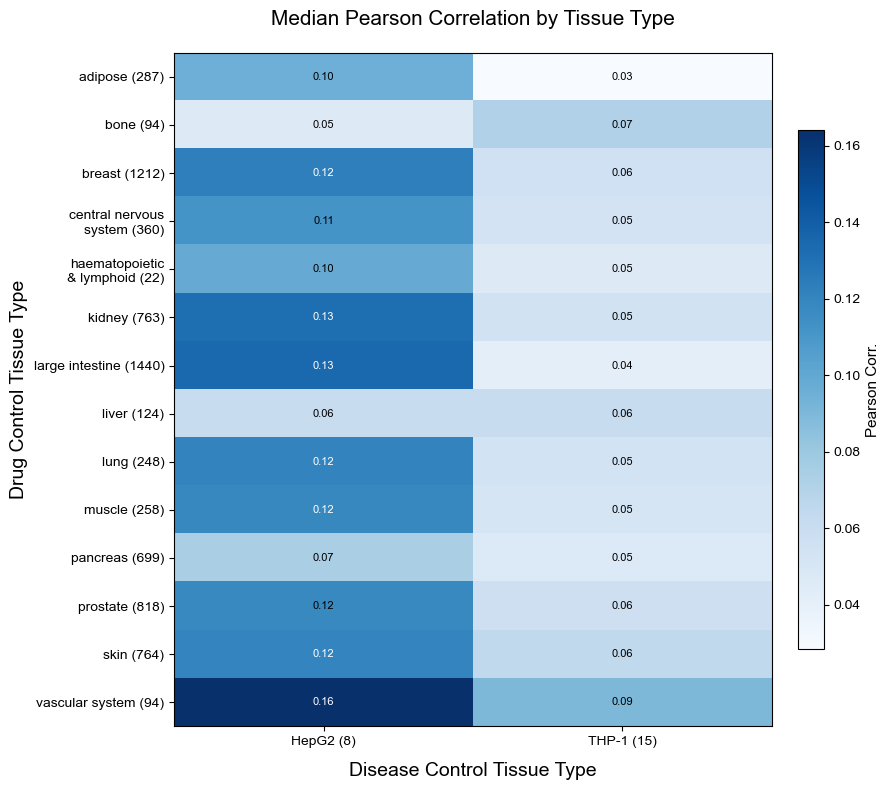

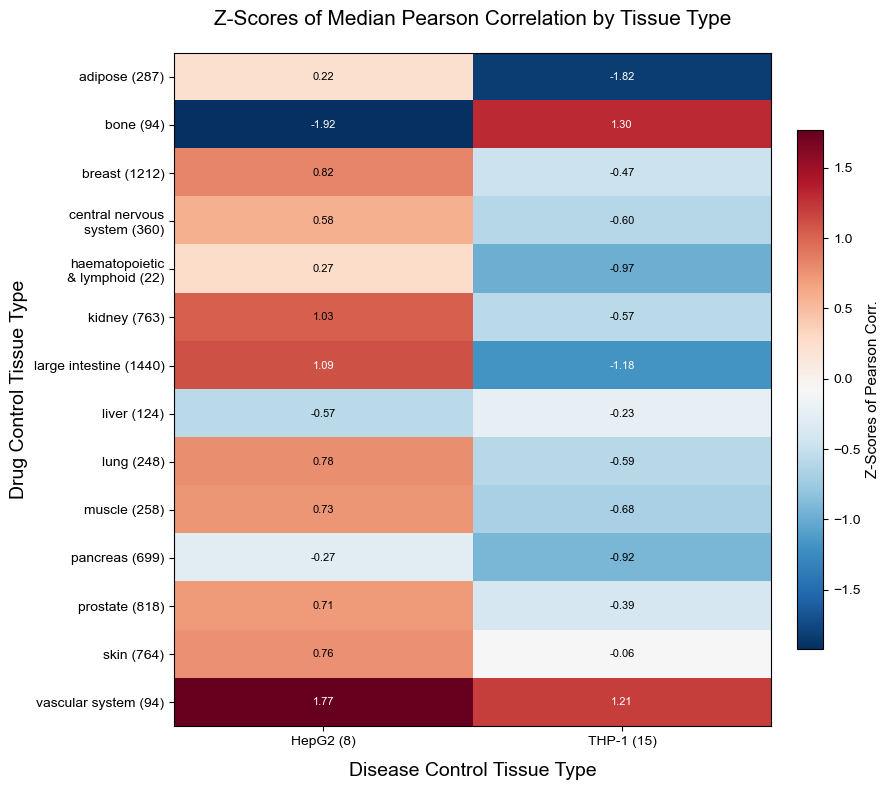

In [114]:

p = pd.read_csv('results/rna_ranks_p_09-01.csv', index_col=0)

# read in 'cell_line_to_tissue.json'
with open('results/cell_line_to_tissue.json', 'r') as f:
    cell_line_tissues = json.load(f)

# Group: tissue → list of cell lines/samples
drug_tissue_groups = defaultdict(list)
for cl, tissue in cell_line_tissues.items():
    drug_tissue_groups[tissue].append(cl)

# disease tissues
disease_tissue_groups = defaultdict(list)
tiss = ['THP-1', 'HepG2']
for sample, tissue in rnaseq_cell[rnaseq_cell.isin(tiss)].items():
    disease_tissue_groups[tissue].append(sample)

# Build tissue x tissue median correlation matrix
drug_tissues = sorted(drug_tissue_groups.keys())
disease_tissues = sorted(disease_tissue_groups.keys())
tissue_matrix = pd.DataFrame(index=drug_tissues, columns=disease_tissues, dtype=float)

for dt in drug_tissues:
    for ds in disease_tissues:
        cell_lines = drug_tissue_groups[dt]
        samples = disease_tissue_groups[ds]
        submatrix = p.loc[p.index.intersection(cell_lines), p.columns.intersection(samples)]
        if not submatrix.empty:
            tissue_matrix.loc[dt, ds] = np.median(submatrix.values)

matrix = tissue_matrix.values.astype(float)[1:, :]

def safe_zscore(matrix, axis):
    mean = np.nanmean(matrix, axis=axis, keepdims=True)  
    std = np.nanstd(matrix, axis=axis, ddof=1, keepdims=True)  
    return (matrix - mean) / std  

row_z_scores = safe_zscore(matrix, axis=1)
col_z_scores = safe_zscore(matrix, axis=0)
matrix_zscores = (row_z_scores + col_z_scores) / np.sqrt(2)

mpl.rcParams['font.family'] = 'Arial'

# Shortened names
dis_tis_name_map = {
    'primary human lymphatic endothelial cell': 'lymphatic endothelial', 
    'PBMCs isolated from Healthy individuals' : 'PBMC',
    'Purified cord blood CD34+ cells': 'cord blood CD34+',
    'monocyte-derived macrophages': 'macrophages',
}
drug_tis_name_map = {
    'haematopoietic and lymphoid tissue': 'haematopoietic\n& lymphoid',
    'central nervous system': 'central nervous\nsystem',
}

# --- Function to add counts to tick labels ---
def add_counts_to_labels(tissues, groups, name_map):
    labels = []
    for t in tissues:
        pretty_name = name_map.get(t, t)
        count = len(groups[t])
        labels.append(f"{pretty_name} ({count})")
    return labels

# tissue -> total number of drug samples (columns) across its cell lines
drug_tissue_sample_counts = {
    tissue: sum(cell_line_counts[cl] for cl in cl_list)
    for tissue, cl_list in drug_tissue_groups.items()
}

def add_counts_to_labels_with_samples(tissues, name_map, sample_counts_dict):
    labels = []
    for t in tissues:
        pretty_name = name_map.get(t, t)
        count = sample_counts_dict.get(t, 0)
        labels.append(f"{pretty_name} ({count})")
    return labels

# Use this for drug tissue labels
ylabels = add_counts_to_labels_with_samples(
    drug_tissues[1:], drug_tis_name_map, drug_tissue_sample_counts
)


# Labels with counts
xlabels = add_counts_to_labels(disease_tissues, disease_tissue_groups, dis_tis_name_map)
# ylabels = add_counts_to_labels(drug_tissues[1:], drug_tissue_groups, drug_tis_name_map)

# --- Function to plot heatmap and add dict key ---
def plot_heatmap(matrix, xlabels, ylabels, title, cbar_label, cmap='Blues', annotate=True, center_zero=False):
    fig, ax = plt.subplots(figsize=(9, 8))
    cax = ax.imshow(matrix, cmap=cmap, aspect='auto')
    clbar = fig.colorbar(cax, ax=ax, orientation='vertical', fraction=0.04, pad=0.04)
    clbar.set_label(cbar_label, fontsize=11)

    if center_zero:
        absmax = np.nanmax(np.abs(matrix)) - 0.5
        vmin, vmax = -absmax, absmax
    else:
        vmin, vmax = np.nanmin(matrix), np.nanmax(matrix)

    if annotate:
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                val = matrix[i, j]
                if not np.isnan(val):
                    if center_zero:
                        ax.text(j, i, f"{val:.2f}", ha='center', va='center',
                                fontsize=8, color='black' if abs(val) < (absmax * 0.75) else 'white')
                    else:
                        ax.text(j, i, f"{val:.2f}", ha='center', va='center',
                                fontsize=8, color='black' if val < np.nanpercentile(matrix, 75) else 'white')

    ax.set_xticks(np.arange(len(xlabels)))
    ax.set_xticklabels(xlabels, rotation=0, fontsize=10)
    ax.set_yticks(np.arange(len(ylabels)))
    ax.set_yticklabels(ylabels, fontsize=10)

    ax.set_xlabel('Disease Control Tissue Type', fontsize=14, labelpad=10)
    ax.set_ylabel('Drug Control Tissue Type', fontsize=14)
    ax.set_title(title, fontsize=15, pad=20)

    # Add the drug tissue → cell line key below the figure 
    # drug_key_text = "\n".join([f"{name}: {', '.join(drug_tissue_groups[name])}" for name in drug_tissues[1:]])
    # plt.figtext(1, 0.7, "Drug Tissue → Cell Line Mapping:\n" + drug_key_text, wrap=False, ha='left', fontsize=10)

    plt.tight_layout()
    plt.show()

# --- Plot both heatmaps ---
plot_heatmap(matrix, xlabels, ylabels,
             'Median Pearson Correlation by Tissue Type',
             'Pearson Corr.')

plot_heatmap(matrix_zscores, xlabels, ylabels,
             'Z-Scores of Median Pearson Correlation by Tissue Type',
             'Z-Scores of Pearson Corr.', cmap='RdBu_r', center_zero=True)


# Tue Sept 16

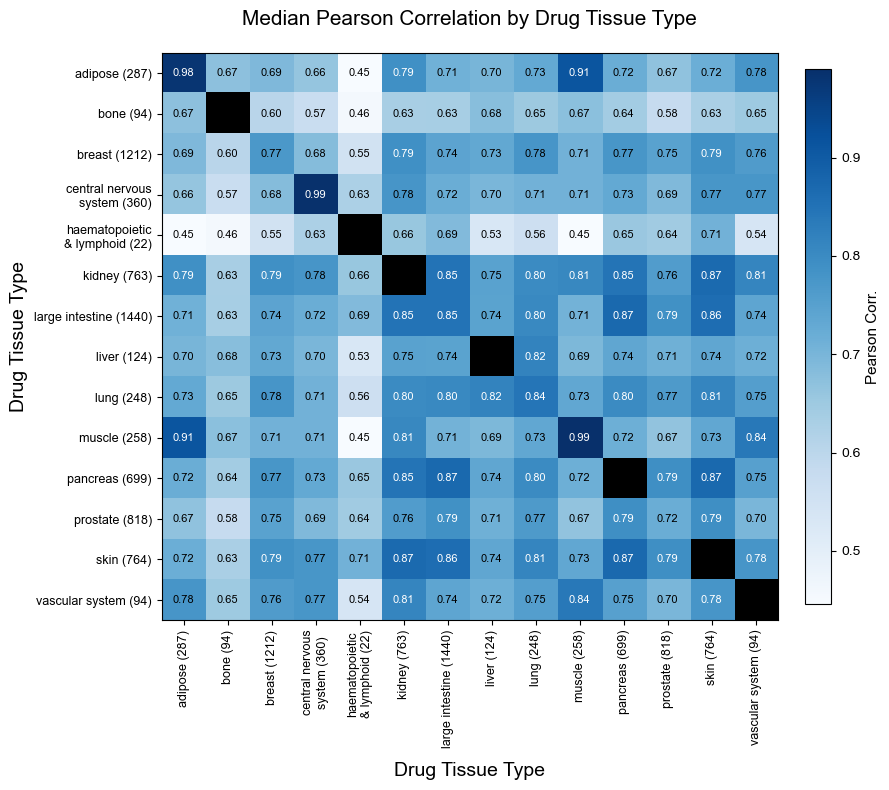

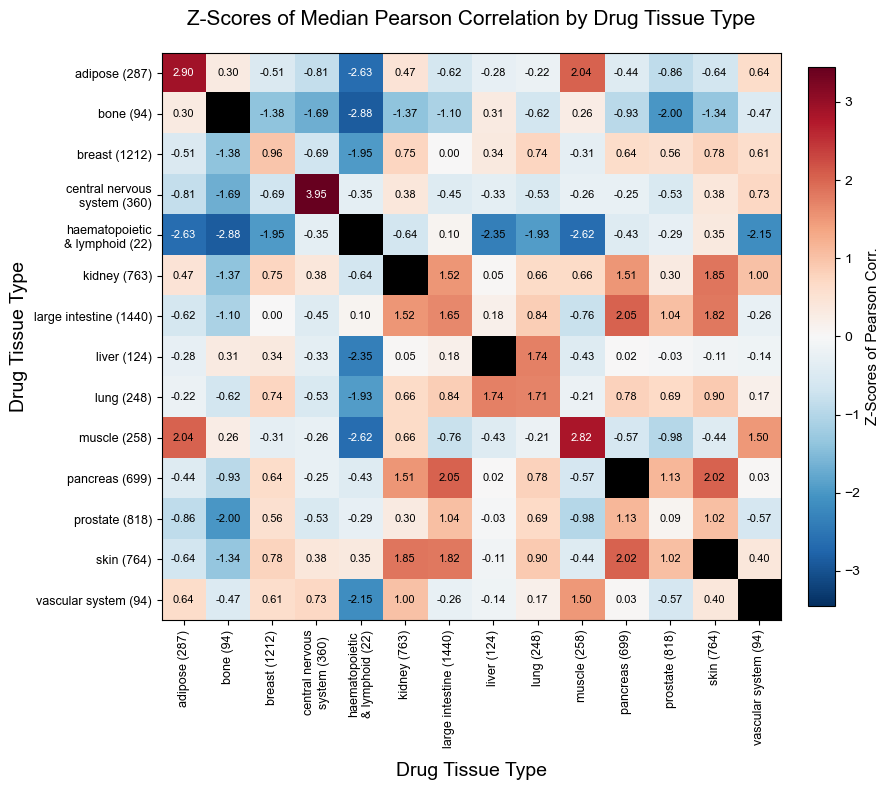

In [108]:
# --- Build tissue × tissue max correlation matrix ---
drug_tissues = sorted(drug_tissue_groups.keys())
tissue_matrix = pd.DataFrame(index=drug_tissues, columns=drug_tissues, dtype=float)

for t1 in drug_tissues:
    for t2 in drug_tissues:
        cell_lines_1 = drug_tissue_groups[t1]
        cell_lines_2 = drug_tissue_groups[t2]

        submatrix = p.loc[
            p.index.intersection(cell_lines_1),
            p.columns.intersection(cell_lines_2)
        ].copy()

        if t1 == t2:
            # Mask out same-cell-line comparisons (diagonal)
            np.fill_diagonal(submatrix.values, np.nan)

        # If there are any remaining values, take max; else NaN
        if np.isfinite(submatrix.values).any():
            tissue_matrix.loc[t1, t2] = np.nanmedian(submatrix.values)
        else:
            tissue_matrix.loc[t1, t2] = np.nan

matrix = tissue_matrix.values.astype(float)[1:, 1:]

# --- Z-score normalization ---
def safe_zscore(matrix, axis):
    mean = np.nanmean(matrix, axis=axis, keepdims=True)  
    std = np.nanstd(matrix, axis=axis, ddof=1, keepdims=True)  
    return (matrix - mean) / std  

row_z_scores = safe_zscore(matrix, axis=1)
col_z_scores = safe_zscore(matrix, axis=0)
matrix_zscores = (row_z_scores + col_z_scores) / np.sqrt(2)

# --- Updated heatmap function with optional center 0 ---
def plot_heatmap(matrix, labels, title, cbar_label, cmap='Blues', annotate=True, center_zero=False):
    fig, ax = plt.subplots(figsize=(9, 8))

    if center_zero:
        absmax = np.nanmax(np.abs(matrix)) - 0.5
        vmin, vmax = -absmax, absmax
    else:
        vmin, vmax = np.nanmin(matrix), np.nanmax(matrix)

    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(color='black')

    cax = ax.imshow(matrix, cmap=cmap_obj, aspect='auto', vmin=vmin, vmax=vmax)
    clbar = fig.colorbar(cax, ax=ax, orientation='vertical', fraction=0.04, pad=0.04)
    clbar.set_label(cbar_label, fontsize=11)

    if annotate:
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                val = matrix[i, j]
                if not np.isnan(val):
                    if center_zero:
                        ax.text(j, i, f"{val:.2f}", ha='center', va='center',
                                fontsize=8, color='black' if abs(val) < (absmax * 0.75) else 'white')
                    else:
                        ax.text(j, i, f"{val:.2f}", ha='center', va='center',
                                fontsize=8, color='black' if val < np.nanpercentile(matrix, 75) else 'white')

    ax.set_xticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=90, fontsize=9)
    ax.set_yticks(np.arange(len(labels)))
    ax.set_yticklabels(labels, fontsize=9)

    ax.set_xlabel('Drug Tissue Type', fontsize=14, labelpad=10)
    ax.set_ylabel('Drug Tissue Type', fontsize=14)
    ax.set_title(title, fontsize=15, pad=20)

    # drug_key_text = "\n".join([f"{name}: {', '.join(drug_tissue_groups[name])}" for name in drug_tissues[1:]])
    # plt.figtext(0, -0.22, "Drug Tissue → Cell Line Mapping:\n" + drug_key_text,
    #             wrap=False, ha='left', fontsize=10)

    plt.tight_layout()
    plt.show()


# --- Plot both heatmaps ---
plot_heatmap(matrix, labels,
             'Median Pearson Correlation by Drug Tissue Type',
             'Pearson Corr.')

plot_heatmap(matrix_zscores, labels,
             'Z-Scores of Median Pearson Correlation by Drug Tissue Type',
             'Z-Scores of Pearson Corr.', cmap='RdBu_r', center_zero=True)


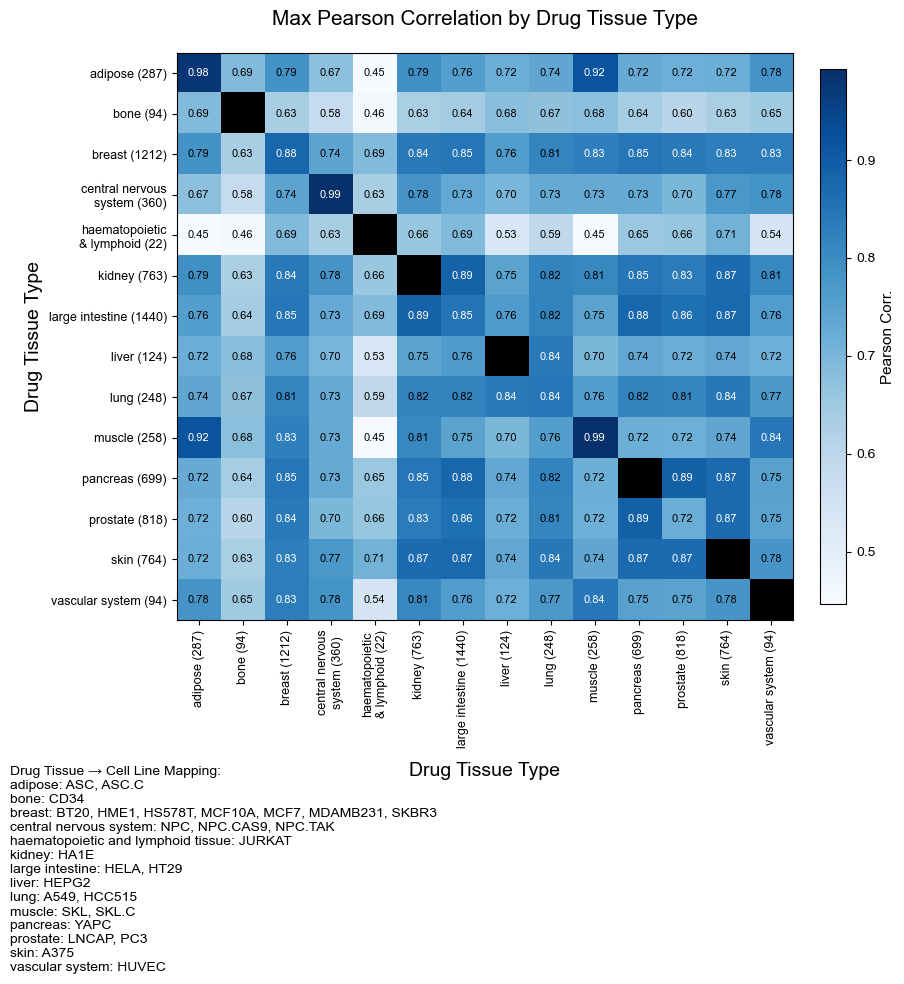

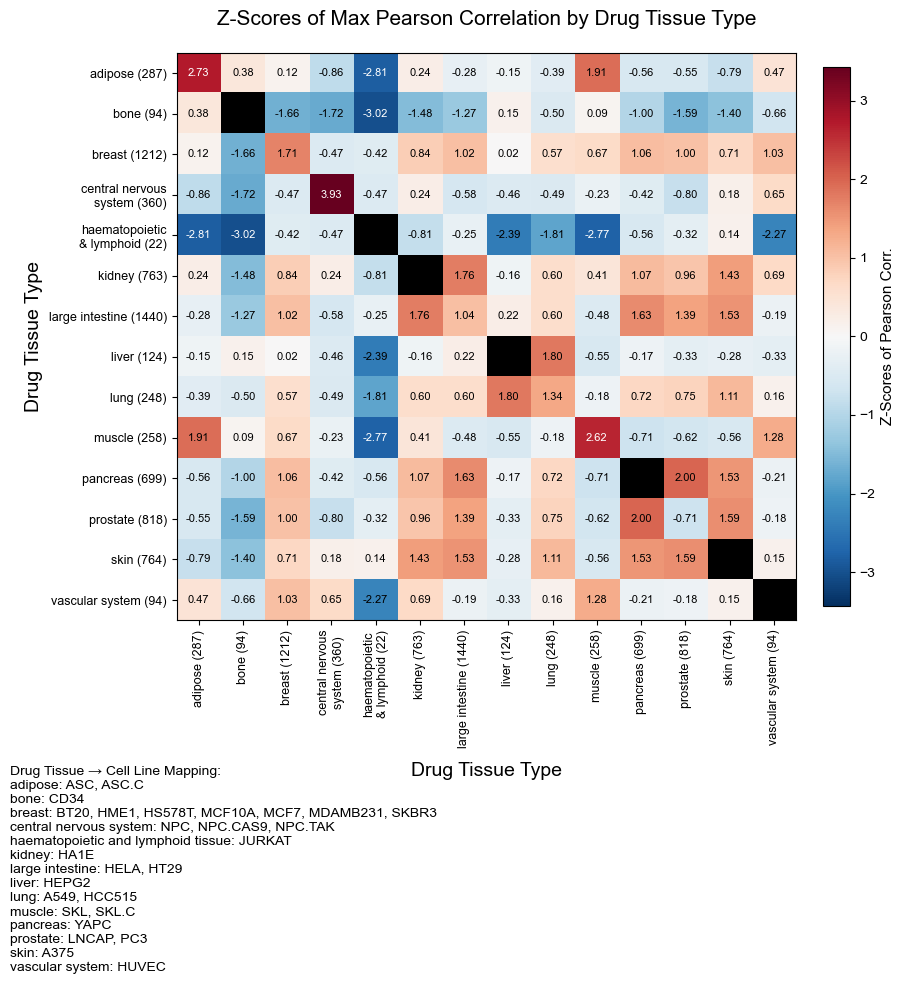

In [107]:
# --- Build tissue × tissue max correlation matrix ---
drug_tissues = sorted(drug_tissue_groups.keys())
tissue_matrix = pd.DataFrame(index=drug_tissues, columns=drug_tissues, dtype=float)

for t1 in drug_tissues:
    for t2 in drug_tissues:
        cell_lines_1 = drug_tissue_groups[t1]
        cell_lines_2 = drug_tissue_groups[t2]

        submatrix = p.loc[
            p.index.intersection(cell_lines_1),
            p.columns.intersection(cell_lines_2)
        ].copy()

        if t1 == t2:
            # Mask out same-cell-line comparisons (diagonal)
            np.fill_diagonal(submatrix.values, np.nan)

        # If there are any remaining values, take max; else NaN
        if np.isfinite(submatrix.values).any():
            tissue_matrix.loc[t1, t2] = np.nanmax(submatrix.values)
        else:
            tissue_matrix.loc[t1, t2] = np.nan

matrix = tissue_matrix.values.astype(float)[1:, 1:]

# --- Z-score normalization ---
def safe_zscore(matrix, axis):
    mean = np.nanmean(matrix, axis=axis, keepdims=True)  
    std = np.nanstd(matrix, axis=axis, ddof=1, keepdims=True)  
    return (matrix - mean) / std  

row_z_scores = safe_zscore(matrix, axis=1)
col_z_scores = safe_zscore(matrix, axis=0)
matrix_zscores = (row_z_scores + col_z_scores) / np.sqrt(2)

# --- Updated heatmap function with optional center 0 ---
def plot_heatmap(matrix, labels, title, cbar_label, cmap='Blues', annotate=True, center_zero=False):
    fig, ax = plt.subplots(figsize=(9, 8))

    if center_zero:
        absmax = np.nanmax(np.abs(matrix)) - 0.5
        vmin, vmax = -absmax, absmax
    else:
        vmin, vmax = np.nanmin(matrix), np.nanmax(matrix)
        
    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(color='black')

    cax = ax.imshow(matrix, cmap=cmap_obj, aspect='auto', vmin=vmin, vmax=vmax)
    clbar = fig.colorbar(cax, ax=ax, orientation='vertical', fraction=0.04, pad=0.04)
    clbar.set_label(cbar_label, fontsize=11)

    if annotate:
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                val = matrix[i, j]
                if not np.isnan(val):
                    if center_zero:
                        ax.text(j, i, f"{val:.2f}", ha='center', va='center',
                                fontsize=8, color='black' if abs(val) < (absmax * 0.75) else 'white')
                    else:
                        ax.text(j, i, f"{val:.2f}", ha='center', va='center',
                                fontsize=8, color='black' if val < np.nanpercentile(matrix, 75) else 'white')

    ax.set_xticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=90, fontsize=9)
    ax.set_yticks(np.arange(len(labels)))
    ax.set_yticklabels(labels, fontsize=9)

    ax.set_xlabel('Drug Tissue Type', fontsize=14, labelpad=10)
    ax.set_ylabel('Drug Tissue Type', fontsize=14)
    ax.set_title(title, fontsize=15, pad=20)

    drug_key_text = "\n".join([f"{name}: {', '.join(drug_tissue_groups[name])}" for name in drug_tissues[1:]])
    plt.figtext(0, -0.22, "Drug Tissue → Cell Line Mapping:\n" + drug_key_text,
                wrap=False, ha='left', fontsize=10)

    plt.tight_layout()
    plt.show()


# --- Plot both heatmaps ---
plot_heatmap(matrix, labels,
             'Max Pearson Correlation by Drug Tissue Type',
             'Pearson Corr.')

plot_heatmap(matrix_zscores, labels,
             'Z-Scores of Max Pearson Correlation by Drug Tissue Type',
             'Z-Scores of Pearson Corr.', cmap='RdBu_r', center_zero=True)


# Sept 13

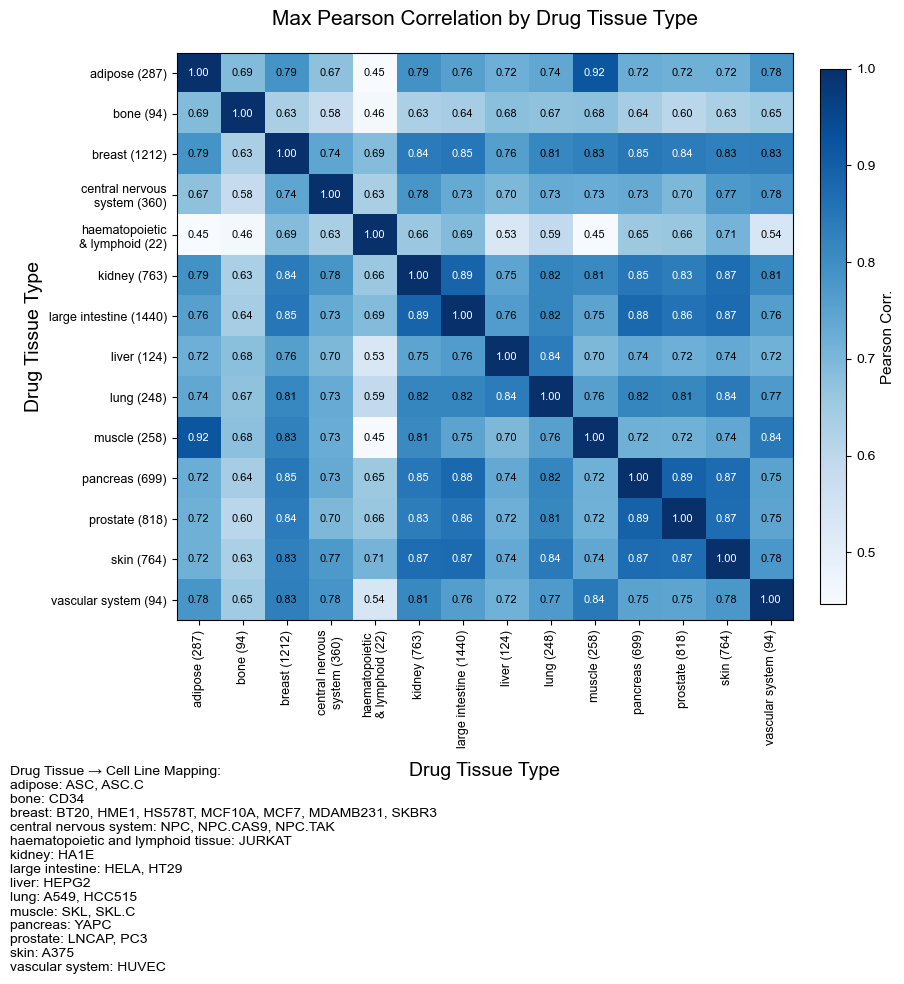

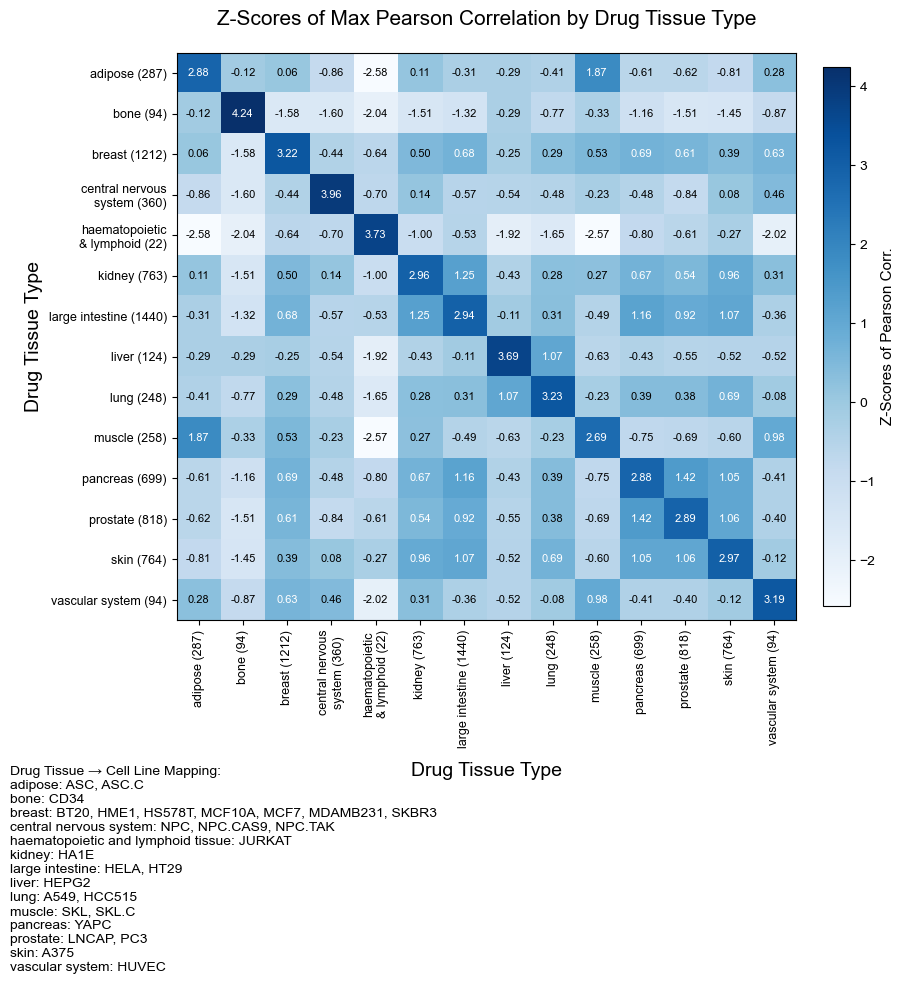

In [98]:

# Read the drug × drug correlation matrix
p = pd.read_csv('results/drug_by_drug_pearson_09-13.csv', index_col=0)

# Read in 'cell_line_to_tissue.json'
with open('results/cell_line_to_tissue.json', 'r') as f:
    cell_line_tissues = json.load(f)

# Group: tissue → list of cell lines
drug_tissue_groups = defaultdict(list)
for cl, tissue in cell_line_tissues.items():
    if cl in p.index:  # only keep cell lines present in correlation matrix
        drug_tissue_groups[tissue].append(cl)

# --- Build tissue × tissue max correlation matrix ---
drug_tissues = sorted(drug_tissue_groups.keys())
tissue_matrix = pd.DataFrame(index=drug_tissues, columns=drug_tissues, dtype=float)

for t1 in drug_tissues:
    for t2 in drug_tissues:
        cell_lines_1 = drug_tissue_groups[t1]
        cell_lines_2 = drug_tissue_groups[t2]

        submatrix = p.loc[
            p.index.intersection(cell_lines_1),
            p.columns.intersection(cell_lines_2)
        ]

        if not submatrix.empty:
            tissue_matrix.loc[t1, t2] = np.max(submatrix.values)

matrix = tissue_matrix.values.astype(float)[1:, 1:]

# --- Z-score normalization ---
def safe_zscore(matrix, axis):
    mean = np.nanmean(matrix, axis=axis, keepdims=True)  
    std = np.nanstd(matrix, axis=axis, ddof=1, keepdims=True)  
    return (matrix - mean) / std  

row_z_scores = safe_zscore(matrix, axis=1)
col_z_scores = safe_zscore(matrix, axis=0)
matrix_zscores = (row_z_scores + col_z_scores) / np.sqrt(2)

mpl.rcParams['font.family'] = 'Arial'

# --- Optional: shorten long tissue names ---
drug_tis_name_map = {
    'haematopoietic and lymphoid tissue': 'haematopoietic\n& lymphoid',
    'central nervous system': 'central nervous\nsystem',
}

# --- Function to add counts to tick labels ---
def add_counts_to_labels(tissues, groups, name_map):
    labels = []
    for t in tissues:
        pretty_name = name_map.get(t, t)
        count = len(groups[t])
        labels.append(f"{pretty_name} ({count})")
    return labels

# tissue -> total number of drug samples (columns) across its cell lines
drug_tissue_sample_counts = {
    tissue: sum(cell_line_counts[cl] for cl in cl_list)
    for tissue, cl_list in drug_tissue_groups.items()
}

def add_counts_to_labels_with_samples(tissues, name_map, sample_counts_dict):
    labels = []
    for t in tissues:
        pretty_name = name_map.get(t, t)
        count = sample_counts_dict.get(t, 0)
        labels.append(f"{pretty_name} ({count})")
    return labels

# Use this for drug tissue labels
labels = add_counts_to_labels_with_samples(
    drug_tissues[1:], drug_tis_name_map, drug_tissue_sample_counts
)

# --- Function to plot heatmap ---
def plot_heatmap(matrix, labels, title, cbar_label, cmap='Blues', annotate=True):
    fig, ax = plt.subplots(figsize=(9, 8))
    cax = ax.imshow(matrix, cmap=cmap, aspect='auto', vmin=np.nanmin(matrix), vmax=np.nanmax(matrix))
    clbar = fig.colorbar(cax, ax=ax, orientation='vertical', fraction=0.04, pad=0.04)
    clbar.set_label(cbar_label, fontsize=11)

    if annotate:
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                val = matrix[i, j]
                if not np.isnan(val):
                    ax.text(j, i, f"{val:.2f}", ha='center', va='center',
                            fontsize=8, color='black' if val < np.nanpercentile(matrix, 75) else 'white')

    ax.set_xticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=90, fontsize=9)
    ax.set_yticks(np.arange(len(labels)))
    ax.set_yticklabels(labels, fontsize=9)

    ax.set_xlabel('Drug Tissue Type', fontsize=14, labelpad=10)
    ax.set_ylabel('Drug Tissue Type', fontsize=14)
    ax.set_title(title, fontsize=15, pad=20)

    # Add the drug tissue → cell line key below the figure 
    drug_key_text = "\n".join([f"{name}: {', '.join(drug_tissue_groups[name])}" for name in drug_tissues[1:]])
    plt.figtext(0, -0.22, "Drug Tissue → Cell Line Mapping:\n" + drug_key_text,
                wrap=False, ha='left', fontsize=10)


    plt.tight_layout()
    plt.show()

# --- Plot both heatmaps ---
plot_heatmap(matrix, labels,
             'Max Pearson Correlation by Drug Tissue Type',
             'Pearson Corr.')

plot_heatmap(matrix_zscores, labels,
             'Z-Scores of Max Pearson Correlation by Drug Tissue Type',
             'Z-Scores of Pearson Corr.')

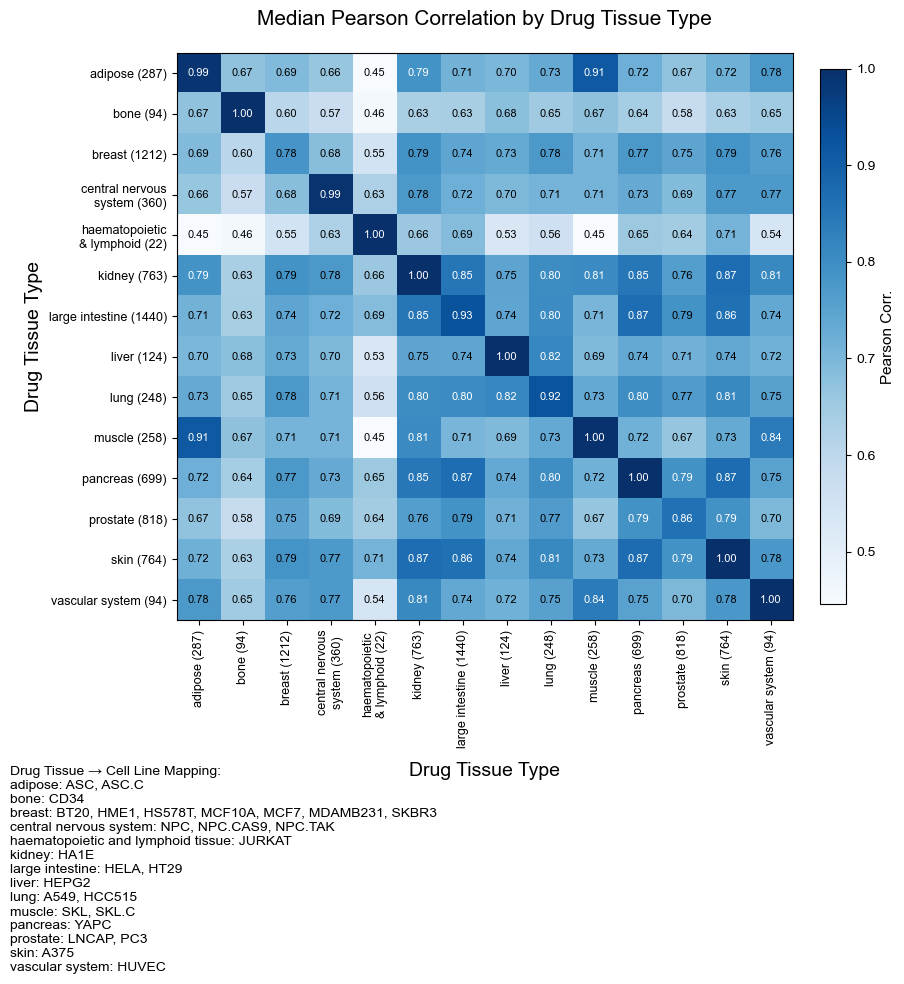

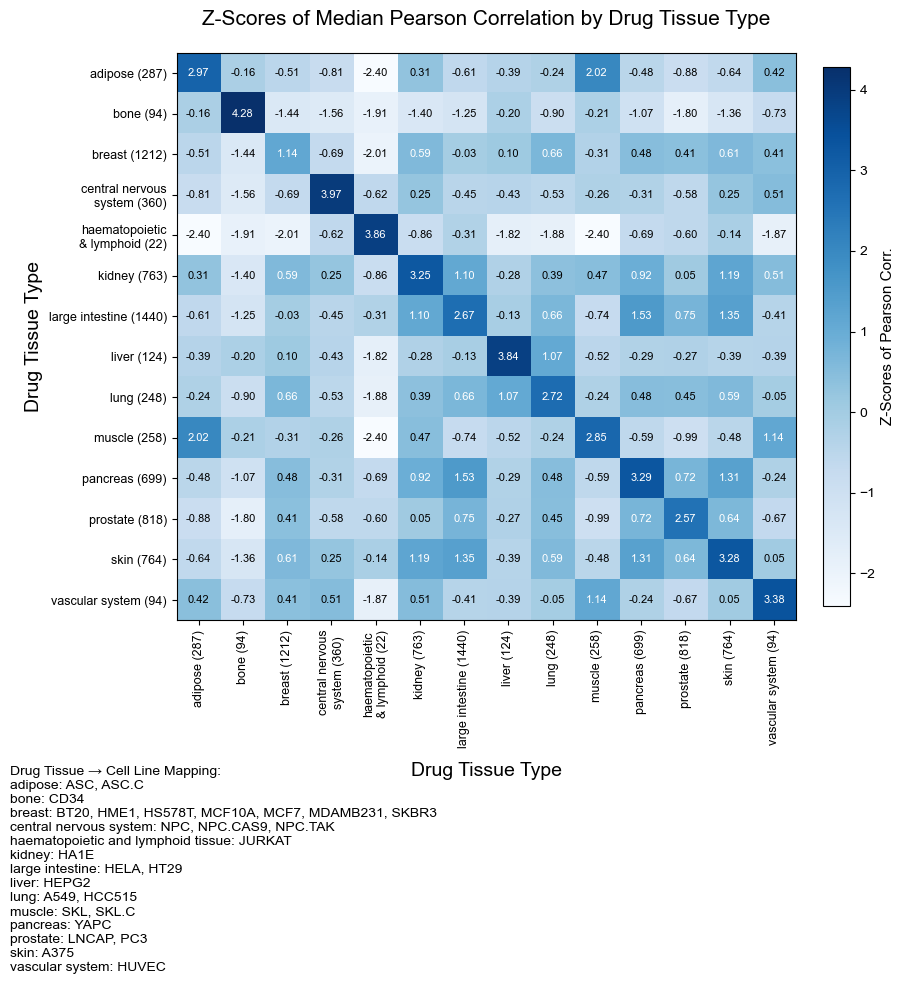

In [100]:

# Read the drug × drug correlation matrix
p = pd.read_csv('results/drug_by_drug_pearson_09-13.csv', index_col=0)

# Read in 'cell_line_to_tissue.json'
with open('results/cell_line_to_tissue.json', 'r') as f:
    cell_line_tissues = json.load(f)

# Group: tissue → list of cell lines
drug_tissue_groups = defaultdict(list)
for cl, tissue in cell_line_tissues.items():
    if cl in p.index:  # only keep cell lines present in correlation matrix
        drug_tissue_groups[tissue].append(cl)

# --- Build tissue × tissue median correlation matrix ---
drug_tissues = sorted(drug_tissue_groups.keys())
tissue_matrix = pd.DataFrame(index=drug_tissues, columns=drug_tissues, dtype=float)

for t1 in drug_tissues:
    for t2 in drug_tissues:
        cell_lines_1 = drug_tissue_groups[t1]
        cell_lines_2 = drug_tissue_groups[t2]

        submatrix = p.loc[
            p.index.intersection(cell_lines_1),
            p.columns.intersection(cell_lines_2)
        ]

        if not submatrix.empty:
            tissue_matrix.loc[t1, t2] = np.median(submatrix.values)

matrix = tissue_matrix.values.astype(float)[1:, 1:]

# --- Z-score normalization ---
def safe_zscore(matrix, axis):
    mean = np.nanmean(matrix, axis=axis, keepdims=True)  
    std = np.nanstd(matrix, axis=axis, ddof=1, keepdims=True)  
    return (matrix - mean) / std  

row_z_scores = safe_zscore(matrix, axis=1)
col_z_scores = safe_zscore(matrix, axis=0)
matrix_zscores = (row_z_scores + col_z_scores) / np.sqrt(2)

mpl.rcParams['font.family'] = 'Arial'

# --- Optional: shorten long tissue names ---
drug_tis_name_map = {
    'haematopoietic and lymphoid tissue': 'haematopoietic\n& lymphoid',
    'central nervous system': 'central nervous\nsystem',
}

# --- Function to add counts to tick labels ---
def add_counts_to_labels(tissues, groups, name_map):
    labels = []
    for t in tissues:
        pretty_name = name_map.get(t, t)
        count = len(groups[t])
        labels.append(f"{pretty_name} ({count})")
    return labels

# tissue -> total number of drug samples (columns) across its cell lines
drug_tissue_sample_counts = {
    tissue: sum(cell_line_counts[cl] for cl in cl_list)
    for tissue, cl_list in drug_tissue_groups.items()
}

def add_counts_to_labels_with_samples(tissues, name_map, sample_counts_dict):
    labels = []
    for t in tissues:
        pretty_name = name_map.get(t, t)
        count = sample_counts_dict.get(t, 0)
        labels.append(f"{pretty_name} ({count})")
    return labels

# Use this for drug tissue labels
labels = add_counts_to_labels_with_samples(
    drug_tissues[1:], drug_tis_name_map, drug_tissue_sample_counts
)

# --- Function to plot heatmap ---
def plot_heatmap(matrix, labels, title, cbar_label, cmap='Blues', annotate=True):
    fig, ax = plt.subplots(figsize=(9, 8))
    cax = ax.imshow(matrix, cmap=cmap, aspect='auto', vmin=np.nanmin(matrix), vmax=np.nanmax(matrix))
    clbar = fig.colorbar(cax, ax=ax, orientation='vertical', fraction=0.04, pad=0.04)
    clbar.set_label(cbar_label, fontsize=11)

    if annotate:
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                val = matrix[i, j]
                if not np.isnan(val):
                    ax.text(j, i, f"{val:.2f}", ha='center', va='center',
                            fontsize=8, color='black' if val < np.nanpercentile(matrix, 75) else 'white')

    ax.set_xticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=90, fontsize=9)
    ax.set_yticks(np.arange(len(labels)))
    ax.set_yticklabels(labels, fontsize=9)

    ax.set_xlabel('Drug Tissue Type', fontsize=14, labelpad=10)
    ax.set_ylabel('Drug Tissue Type', fontsize=14)
    ax.set_title(title, fontsize=15, pad=20)

    # Add the drug tissue → cell line key below the figure 
    drug_key_text = "\n".join([f"{name}: {', '.join(drug_tissue_groups[name])}" for name in drug_tissues[1:]])
    plt.figtext(0, -0.22, "Drug Tissue → Cell Line Mapping:\n" + drug_key_text,
                wrap=False, ha='left', fontsize=10)


    plt.tight_layout()
    plt.show()

# --- Plot both heatmaps ---
plot_heatmap(matrix, labels,
             'Median Pearson Correlation by Drug Tissue Type',
             'Pearson Corr.')

plot_heatmap(matrix_zscores, labels,
             'Z-Scores of Median Pearson Correlation by Drug Tissue Type',
             'Z-Scores of Pearson Corr.')

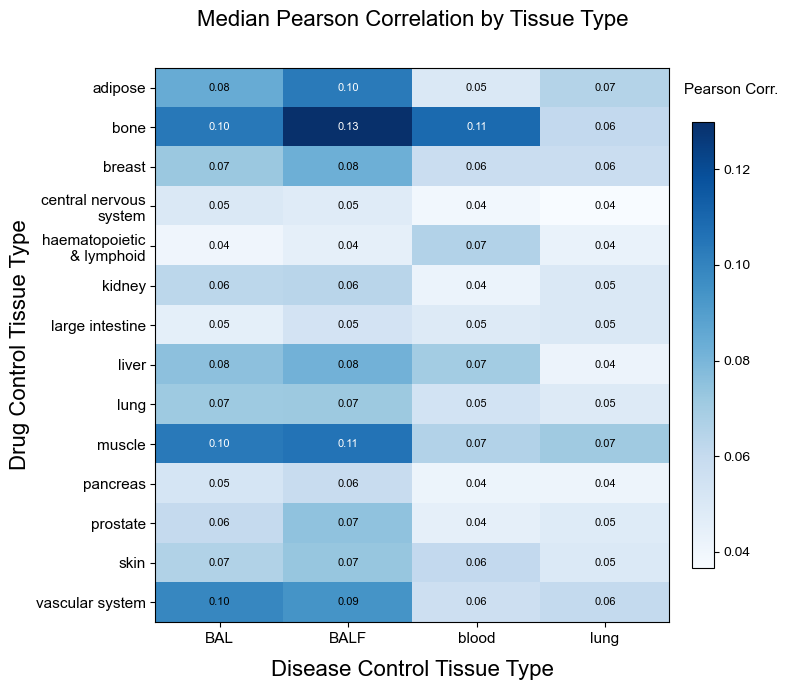

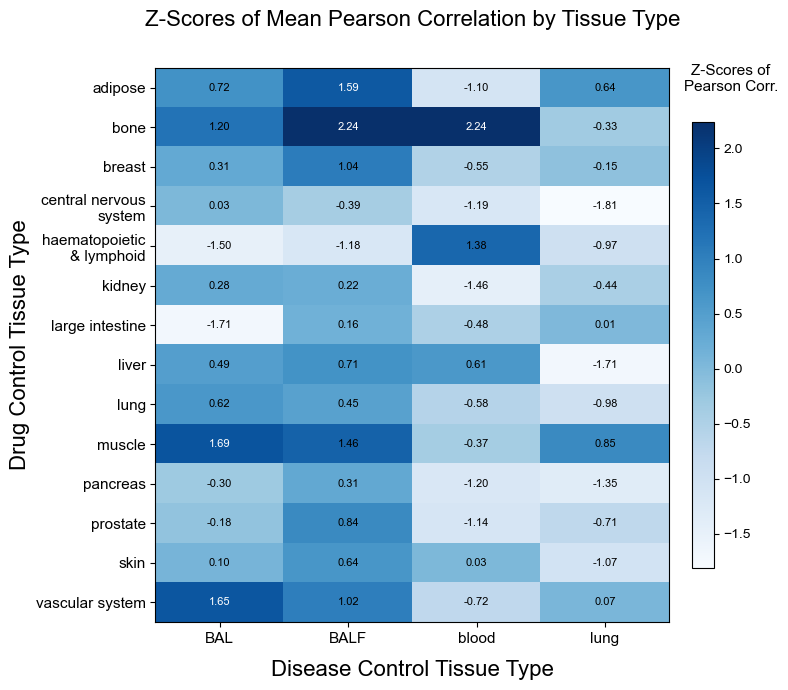

In [41]:
p = pd.read_csv('results/rna_ranks_p_09-01.csv', index_col=0)

# read in 'cell_line_to_tissue.json'
import json
from collections import defaultdict
with open('results/cell_line_to_tissue.json', 'r') as f:
    cell_line_tissues = json.load(f)

# Group: tissue → list of cell lines/samples
drug_tissue_groups = defaultdict(list)
for cl, tissue in cell_line_tissues.items():
    drug_tissue_groups[tissue].append(cl)

disease_tissue_groups = defaultdict(list)
tiss = rnaseq_tissue.value_counts()[rnaseq_tissue.value_counts() > 10].index
for sample, tissue in rnaseq_tissue[rnaseq_tissue.isin(tiss)].items(): # change this for tissue mapping
    disease_tissue_groups[tissue].append(sample)

# Build tissue x tissue median correlation matrix
drug_tissues = sorted(drug_tissue_groups.keys())
disease_tissues = sorted(disease_tissue_groups.keys())
tissue_matrix = pd.DataFrame(index=drug_tissues, columns=disease_tissues, dtype=float)

for dt in drug_tissues:
    for ds in disease_tissues:
        cell_lines = drug_tissue_groups[dt]
        samples = disease_tissue_groups[ds]
        submatrix = p.loc[p.index.intersection(cell_lines), p.columns.intersection(samples)]
        if not submatrix.empty:
            tissue_matrix.loc[dt, ds] = np.median(submatrix.values)

matrix = tissue_matrix.values.astype(float)[1:, :]

def safe_zscore(matrix, axis):
    mean = np.nanmean(matrix, axis=axis, keepdims=True)  # Ignore NaNs in mean calculation
    std = np.nanstd(matrix, axis=axis, ddof=1, keepdims=True)  # Ignore NaNs in std calculation
    return (matrix - mean) / std  # Standardize
# Compute row-wise and column-wise z-scores while ignoring NaNs
row_z_scores = safe_zscore(matrix, axis=1)
col_z_scores = safe_zscore(matrix, axis=0)
# Combine row-wise and column-wise z-scores
matrix_zscores = (row_z_scores + col_z_scores) / np.sqrt(2)


# Plotting heatmap
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Arial'
dis_tis_name_map = {'primary human lymphatic endothelial cell': 'lymphatic endothelial', 
                    'PBMCs isolated from Healthy individuals' : 'PBMC',
                    'Purified cord blood CD34+ cells': 'cord blood CD34+',
                    'monocyte-derived macrophages': 'macrophages',}
drug_tis_name_map = {'haematopoietic and lymphoid tissue': 'haematopoietic\n& lymphoid', 'central nervous system': 'central nervous\nsystem',}
fig, ax = plt.subplots(figsize=(8, 7))
cax = ax.imshow(matrix, cmap='Blues', aspect='auto')
clbar = fig.colorbar(cax, ax=ax, orientation='vertical', fraction=0.04, pad=0.04)

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        ax.text(j, i, f"{matrix[i, j]:.2f}", ha='center', va='center', fontsize=8, color='black' if matrix[i, j]<.1 else 'white')

# plt.text(-.18, 1.02, 'Drug Control Tissue Type', fontsize=16, ha='center', va='center', transform=ax.transAxes)
plt.text(1.12, 0.96, 'Pearson Corr.', fontsize=11, ha='center', va='center', transform=ax.transAxes)
plt.xticks(np.arange(len(disease_tissues)), pd.Series(disease_tissues).apply(lambda x: dis_tis_name_map.get(x, x)).values, rotation=0, fontsize=11)
plt.yticks(np.arange(len(drug_tissues[1:])), pd.Series(drug_tissues[1:]).apply(lambda x: drug_tis_name_map.get(x, x)).values, fontsize=11)
plt.xlabel('Disease Control Tissue Type', fontsize=16, labelpad=10)
plt.ylabel('Drug Control Tissue Type', fontsize=16)
plt.title('Median Pearson Correlation by Tissue Type', fontsize=16, pad=30)
plt.tight_layout()
plt.show()


mpl.rcParams['font.family'] = 'Arial'
dis_tis_name_map = {'primary human lymphatic endothelial cell': 'lymphatic endothelial', 
                    'PBMCs isolated from Healthy individuals' : 'PBMC',
                    'Purified cord blood CD34+ cells': 'cord blood CD34+',
                    'monocyte-derived macrophages': 'macrophages',}
drug_tis_name_map = {'haematopoietic and lymphoid tissue': 'haematopoietic\n& lymphoid', 'central nervous system': 'central nervous\nsystem',}
fig, ax = plt.subplots(figsize=(8, 7))
cax = ax.imshow(matrix_zscores, cmap='Blues', aspect='auto')
clbar = fig.colorbar(cax, ax=ax, orientation='vertical', fraction=0.04, pad=0.04)

for i in range(matrix_zscores.shape[0]):
    for j in range(matrix_zscores.shape[1]):
        ax.text(j, i, f"{matrix_zscores[i, j]:.2f}", ha='center', va='center', fontsize=8, color='black' if matrix_zscores[i, j]<1.5 else 'white')

# plt.text(-.18, 1.02, 'Drug Control Tissue Type', fontsize=16, ha='center', va='center', transform=ax.transAxes)
plt.text(1.12, 0.98, 'Z-Scores of\nPearson Corr.', fontsize=11, ha='center', va='center', transform=ax.transAxes)
plt.xticks(np.arange(len(disease_tissues)), pd.Series(disease_tissues).apply(lambda x: dis_tis_name_map.get(x, x)).values, rotation=0, fontsize=11)
plt.yticks(np.arange(len(drug_tissues[1:])), pd.Series(drug_tissues[1:]).apply(lambda x: drug_tis_name_map.get(x, x)).values, fontsize=11)
plt.xlabel('Disease Control Tissue Type', fontsize=16, labelpad=10)
plt.ylabel('Drug Control Tissue Type', fontsize=16)
plt.title('Z-Scores of Mean Pearson Correlation by Tissue Type', fontsize=16, pad=30)
plt.tight_layout()
plt.show()

In [38]:
rnaseq_cell.value_counts()

CELL
Missing                         40
PBMC                            28
alveolar_macrophage             22
bronchoalveolar_lavage          16
THP-1                           15
NK                              13
monocytes                       12
monocyte_derived_macrophage     11
dendritic_cells                  9
macrophage                       9
HepG2                            8
ILC3pos                          8
ILC1                             8
monocyte_derived_macrophages     8
ILC3neg                          7
ILC2                             7
susp                             7
AM                               7
gd                               6
NKT                              6
blood                            6
endo                             5
epi                              5
mait                             5
marcophages                      4
lymphatic_endothelial_cell       2
Name: count, dtype: int64

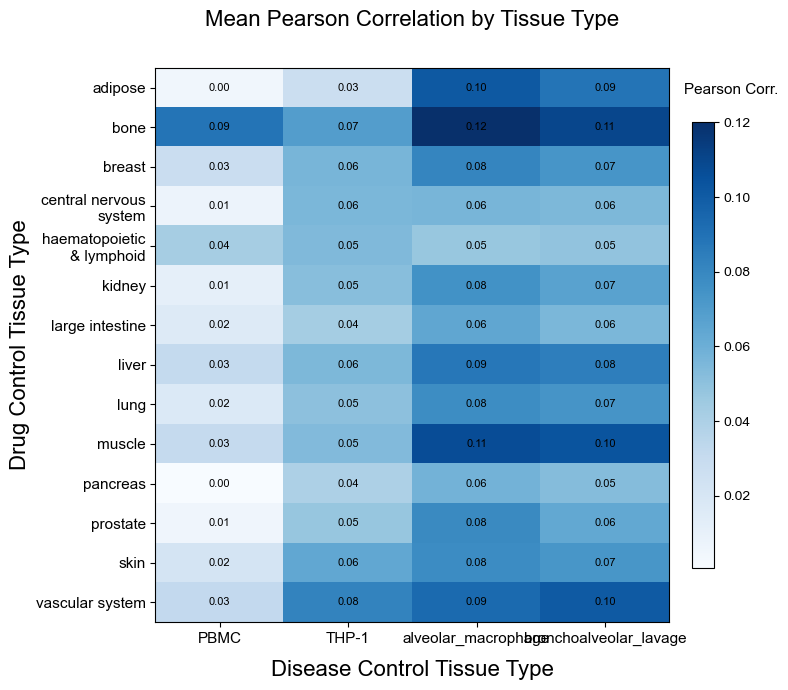

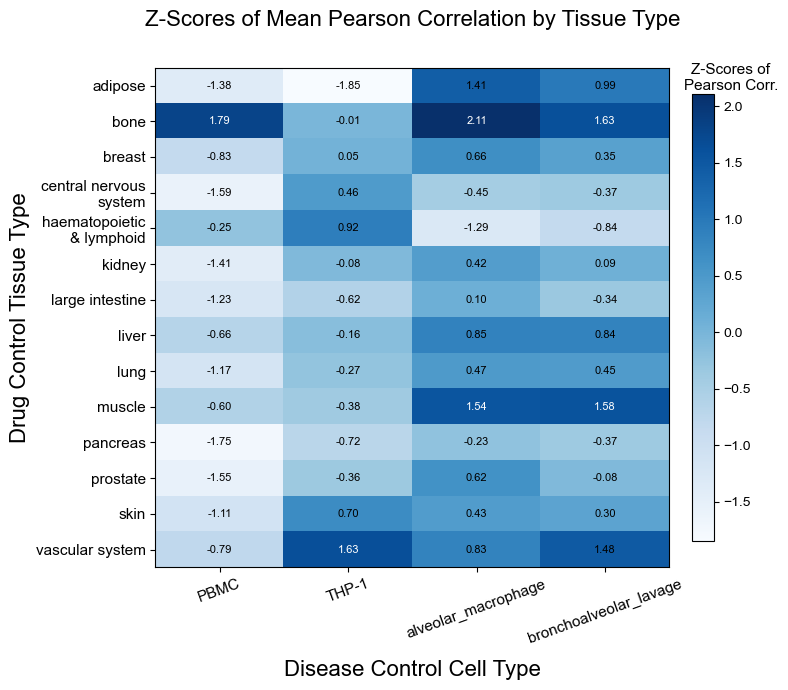

In [35]:
p = pd.read_csv('results/rna_ranks_p_09-01.csv', index_col=0)

# read in 'cell_line_to_tissue.json'
import json
from collections import defaultdict
with open('results/cell_line_to_tissue.json', 'r') as f:
    cell_line_tissues = json.load(f)

# Group: tissue → list of cell lines/samples
drug_tissue_groups = defaultdict(list)
for cl, tissue in cell_line_tissues.items():
    drug_tissue_groups[tissue].append(cl)

disease_tissue_groups = defaultdict(list)
cell = rnaseq_cell.value_counts()[rnaseq_cell.value_counts() > 14].index
cell = cell.drop('Missing')

for sample, tissue in rnaseq_cell[rnaseq_cell.isin(cell)].items(): # change this for tissue mapping
    disease_tissue_groups[tissue].append(sample)

# Build tissue x tissue mean correlation matrix
drug_tissues = sorted(drug_tissue_groups.keys())
disease_tissues = sorted(disease_tissue_groups.keys())
tissue_matrix = pd.DataFrame(index=drug_tissues, columns=disease_tissues, dtype=float)

for dt in drug_tissues:
    for ds in disease_tissues:
        cell_lines = drug_tissue_groups[dt]
        samples = disease_tissue_groups[ds]
        submatrix = p.loc[p.index.intersection(cell_lines), p.columns.intersection(samples)]
        if not submatrix.empty:
            tissue_matrix.loc[dt, ds] = submatrix.values.mean()

matrix = tissue_matrix.values.astype(float)[1:, :]

def safe_zscore(matrix, axis):
    mean = np.nanmean(matrix, axis=axis, keepdims=True)  # Ignore NaNs in mean calculation
    std = np.nanstd(matrix, axis=axis, ddof=1, keepdims=True)  # Ignore NaNs in std calculation
    return (matrix - mean) / std  # Standardize
# Compute row-wise and column-wise z-scores while ignoring NaNs
row_z_scores = safe_zscore(matrix, axis=1)
col_z_scores = safe_zscore(matrix, axis=0)
# Combine row-wise and column-wise z-scores
matrix_zscores = (row_z_scores + col_z_scores) / np.sqrt(2)


# Plotting heatmap
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Arial'
dis_tis_name_map = {'primary human lymphatic endothelial cell': 'lymphatic endothelial', 
                    'PBMCs isolated from Healthy individuals' : 'PBMC',
                    'Purified cord blood CD34+ cells': 'cord blood CD34+',
                    'monocyte-derived macrophages': 'macrophages',}
drug_tis_name_map = {'haematopoietic and lymphoid tissue': 'haematopoietic\n& lymphoid', 'central nervous system': 'central nervous\nsystem',}
fig, ax = plt.subplots(figsize=(8, 7))
cax = ax.imshow(matrix, cmap='Blues', aspect='auto')
clbar = fig.colorbar(cax, ax=ax, orientation='vertical', fraction=0.04, pad=0.04)

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        ax.text(j, i, f"{matrix[i, j]:.2f}", ha='center', va='center', fontsize=8, color='black' if matrix[i, j]<1.5 else 'white')

# plt.text(-.18, 1.02, 'Drug Control Tissue Type', fontsize=16, ha='center', va='center', transform=ax.transAxes)
plt.text(1.12, 0.96, 'Pearson Corr.', fontsize=11, ha='center', va='center', transform=ax.transAxes)
plt.xticks(np.arange(len(disease_tissues)), pd.Series(disease_tissues).apply(lambda x: dis_tis_name_map.get(x, x)).values, rotation=0, fontsize=11)
plt.yticks(np.arange(len(drug_tissues[1:])), pd.Series(drug_tissues[1:]).apply(lambda x: drug_tis_name_map.get(x, x)).values, fontsize=11)
plt.xlabel('Disease Control Tissue Type', fontsize=16, labelpad=10)
plt.ylabel('Drug Control Tissue Type', fontsize=16)
plt.title('Mean Pearson Correlation by Tissue Type', fontsize=16, pad=30)
plt.tight_layout()
plt.show()


mpl.rcParams['font.family'] = 'Arial'
dis_tis_name_map = {'primary human lymphatic endothelial cell': 'lymphatic endothelial', 
                    'PBMCs isolated from Healthy individuals' : 'PBMC',
                    'Purified cord blood CD34+ cells': 'cord blood CD34+',
                    'monocyte-derived macrophages': 'macrophages',}
drug_tis_name_map = {'haematopoietic and lymphoid tissue': 'haematopoietic\n& lymphoid', 'central nervous system': 'central nervous\nsystem',}
fig, ax = plt.subplots(figsize=(8, 7))
cax = ax.imshow(matrix_zscores, cmap='Blues', aspect='auto')
clbar = fig.colorbar(cax, ax=ax, orientation='vertical', fraction=0.04, pad=0.04)

for i in range(matrix_zscores.shape[0]):
    for j in range(matrix_zscores.shape[1]):
        ax.text(j, i, f"{matrix_zscores[i, j]:.2f}", ha='center', va='center', fontsize=8, color='black' if matrix_zscores[i, j]<1.5 else 'white')

# plt.text(-.18, 1.02, 'Drug Control Tissue Type', fontsize=16, ha='center', va='center', transform=ax.transAxes)
plt.text(1.12, 0.98, 'Z-Scores of\nPearson Corr.', fontsize=11, ha='center', va='center', transform=ax.transAxes)
plt.xticks(np.arange(len(disease_tissues)), pd.Series(disease_tissues).apply(lambda x: dis_tis_name_map.get(x, x)).values, rotation=20, fontsize=11)
plt.yticks(np.arange(len(drug_tissues[1:])), pd.Series(drug_tissues[1:]).apply(lambda x: drug_tis_name_map.get(x, x)).values, fontsize=11)
plt.xlabel('Disease Control Cell Type', fontsize=16, labelpad=10)
plt.ylabel('Drug Control Tissue Type', fontsize=16)
plt.title('Z-Scores of Mean Pearson Correlation by Tissue Type', fontsize=16, pad=30)
plt.tight_layout()
plt.show()

In [19]:
for file_name in os.listdir('data/expression/rnaseq/'):
    if file_name.split('.')[0] in new_gse:
        print('yes')
    else:
        print('no')

no
yes
no
yes
no
yes
yes
yes
yes
yes
no


In [15]:
print(len(new_gsm))
print(len(rnaseq_dis_data.columns.values))
print(np.isin(new_gsm, rnaseq_dis_data.columns.values).mean())
print(np.isin(rnaseq_dis_data.columns.values, new_gsm).mean())

938
167
0.11194029850746269
0.6287425149700598


In [24]:
cont = dfc.get_disease_controls()
print(len(new_gsm))
print(len(cont))
print(np.isin(new_gsm, cont).mean())
print(np.isin(cont, new_gsm).mean())


938
438
0.15458422174840086
0.3310502283105023
